In [111]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy

****
## Problem 1
part a

In [2]:
def sample_variance(x,formula='original'):
    # four formulae are orginal, squares, and welford
    
    
    n = len(x)
    
    if formula=='original':
        x_bar = np.mean(x)
        
        vec = x-x_bar
        
        svar = vec.dot(vec)/(n-1)
        
        return svar
    
    if formula=='squares':
        
        svar = (np.sum(x*x)-np.sum(x)**2/n)/(n-1)
        
        return svar
    
    if formula=='welford':
        
        mk = x[0]
        qk = 0
        
        for i in np.arange(1,n):
            m_prev = mk
            q_prev = qk
            
            mk = m_prev + (x[i] - m_prev)/(i+1)
            qk = q_prev + i*(x[i]-m_prev)**2/(i+1)
            
        return qk/(n-1)

part b

In [3]:
n= 1000

x = np.random.normal(1e9,1,n)

sample_variance(x,formula='original')

0.9266710749764882

In [4]:
sample_variance(x,formula='squares')

262.4064064064064

Note that the above is uhh, not very close to $1$.

In [5]:
sample_variance(x,formula='welford')

0.9266711075543586

part c

In [6]:
m = 10000
n = 1000


reg = []
sq = []
wel = []
for i in range(m):
    
    x = np.random.normal(1e9,1,n)
    
    reg.append(sample_variance(x,formula='original'))
    sq.append(sample_variance(x,formula='squares'))
    wel.append(sample_variance(x,formula='welford'))

<BarContainer object of 20 artists>

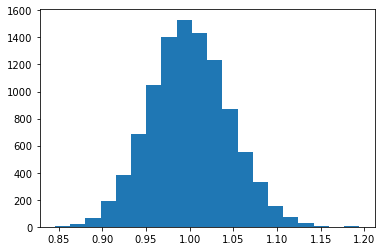

In [7]:
plt.hist(reg,20)[-1]

<BarContainer object of 20 artists>

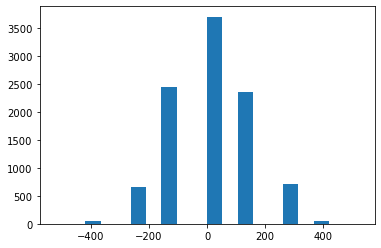

In [8]:
plt.hist(sq,20)[-1]

<BarContainer object of 20 artists>

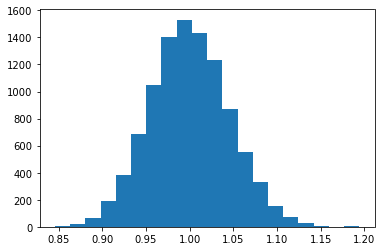

In [9]:
plt.hist(wel,20)[-1]

In the second histogram, we are seeing the results of numerical instability. When each $x_i\approx 10^9$, $n=1000$,
$$
(\sum_{i=1}^nx_i)^2\approx(\sum_{i=1}^{1000}10^9)^2=10^24
$$

****
## Problem 2

In [146]:
def my_solve_plu(L,U,p,b,pivoting=None):
    'given PA = LU, this function solves Ax=b'

    # size of the problem
    n = len(b)
    
    # initialize vectors x and y
    y = np.zeros(n)
    x = np.zeros(n)
    
    # permute b
    bp = b[p]

    # solve Ly = bp
    for i in range(n):
        y[i] = bp[i] - L[i,0:i].dot(y[0:i])

    # solve Ux = y
    for i in reversed(range(n)): # i = n,...,1
        x[i] = (y[i] - U[i,i+1:n].dot(x[i+1:n]))/U[i,i]

    return x

In [147]:
def update_solutions(L,U,p,b,x_old,i,j, Aij_old,Aij_new):
    n = len(x_old)
    u = np.zeros(n)
    u[i] = 1
    v = np.zeros(n)
    v[j] = Aij_new - Aij_old
    
    coeff = 1/(1+v.dot(my_solve_plu(L,U,p,u))) #O(n^2) to calculate A^{-1}u, O(n) for other steps
    
    # we don't care as much about A^{-1} as we care about what it does to the vector b, which we can find
    # by working right-to left in the Sherman-Morrison equation
    
    partial = x_old.copy() # A^{-1}b, which is equal to x_old
    
    partial = v.dot(partial) # v^TA^{-1}b, a scalar, found in O(n) steps
    
    partial = u*partial # uv^TA^{-1}b, a vector, found in O(n) steps
    
    partial = my_solve_plu(L,U,p,partial) # A^{-1}uv^TA^{-1}b, a vector, found in O(n^2) steps
    
    partial = coeff*partial # scalar times vector found in O(n) steps
    
    x_new = x_old - partial # yields A^{-1}b - A^{-1}uv^TA^{-1}b, difference of vectors, O(n) steps
    
    return x_old # no step exceeds O(n^2) operations

## Problem 3

In [154]:
# I operate under the assumption that the 'smallest eigenvalue' is the eigenvalue closest to 0. I don't know 
# how else one can ensure that their guessed shift is 'small' enough (ie most negative)

def smallest_root(a):
    # a is the list of coefficients, ignoring the leading coeff as we assume p is monic

    deg = len(a)
    
    v = -a.copy()
    v[-1] = v[-1] - 1
    
    u = np.zeros(n)
    u[0] = 1
    
    p_inv = np.zeros
    p_inv[0:n-1] = np.arange(1,n-1)
    
    b_prev = np.ones(n)
    b = np.ones(n)
    
    # do inverse iteration using sherman morrison
    
    for i in range(100):
        b_prev = b
        b_hat = b_prev[p_inv] - (-1/a[-1])*(u*v.T.dot(b_prev[p_inv]))[p_inv] # O(n)steps
        b = b_hat/np.linalg.norm(b_hat)
        
    #b is our approximation of the unit eigenvector in the direction of the smallest eigenvalue.
    
    # find its length after multiplication by C to approximate smallest eigenvalue.
        
    C = np.zeros((n,n))
    C[0,:] = coeffs
    
    for i in range(1,n):
        C[i,i-1] = 1
                                            
    return np.linalg.norm(C.dot(b))              

## Problem 4

In [144]:
def my_LU(A,pivoting=None):
    'this function factors A into lower L x upper U. It uses 1 for-loop'
    
    n,m = A.shape # size of matrix A
    if m!=n: # check if A is square
        print('WARNING: A must be a square matrix') # print a warning massage
        return  
    
    # initialize U and L factors: issues arise when they arent given in this complex form
    U = A.copy() +1j*np.zeros(n)
    L = np.diag(np.ones(n)+1j*np.zeros(n))
    
    
    # Gaussian Elimination steps
    for i in range(n): 
        # multipliers 
        L[i+1:n,i] = U[i+1:n,i]/U[i,i] 
        # update U
        U[i+1:n,i] = 0 
        U[i+1:n,i+1:n] = U[i+1:n,i+1:n] - np.outer(L[i+1:n,i],U[i,i+1:n]) # update U

    return L,U

In [141]:
def LU_eig(A):
    n = A.shape[0]
    H = A.copy()
    H = scipy.linalg.hessenberg(H)
    for j in range(1,n):
        while np.abs(H[n-1,n-2])>1e-16*(np.abs(H[n-2,n-2])+np.abs(H[n-1,n-1])):
            shift = H[n-1,n-1]
            complex_id = np.diag(np.ones(n)+1j*np.zeros(n))
            L,U = my_LU(H[0:n,0:n]-shift*complex_id)
            H[0:n,0:n] = U.dot(L) + shift*complex_id
        n = n-1
    evalues = np.diag(H)
    return evalues

In [142]:
n = 10
A = np.random.randn(n, n) + 1j * np.random.randn(n, n)

np.sort(LU_eig(A))

array([-3.44903445+3.5196092j , -3.21522915-0.44682868j,
       -0.94848435-0.90399685j, -0.23467064-2.76249843j,
        0.88298365+0.64453942j,  1.42785274-1.27866913j,
        1.48225913+3.191693j  ,  1.9346539 +1.61995262j,
        2.24193859-4.52536235j,  2.43277935+3.96928625j])

In [143]:
np.sort(np.linalg.eig(A)[0])

array([-3.44903445+3.5196092j , -3.21522915-0.44682868j,
       -0.94848435-0.90399685j, -0.23467064-2.76249843j,
        0.88298365+0.64453942j,  1.42785274-1.27866913j,
        1.48225913+3.191693j  ,  1.9346539 +1.61995262j,
        2.24193859-4.52536235j,  2.43277935+3.96928625j])

## Problem 5


In [3]:
import scipy.special as sp

In [12]:
k = 11

xk = np.arange(k)/10

yk = sp.erf(xk)

In [13]:
xk

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [14]:
yk

array([0.        , 0.11246292, 0.22270259, 0.32862676, 0.42839236,
       0.52049988, 0.60385609, 0.67780119, 0.74210096, 0.79690821,
       0.84270079])

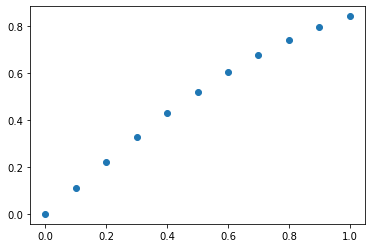

In [15]:
plt.scatter(xk,yk)

In [19]:
coeffs = []

plots = []

for i in range(10):
    deg = i+1
    A = np.zeros((k,deg+1))
    for j in range(deg+1):
        A[:,j] = xk**j
    coeffs.append(np.linalg.lstsq(A,yk,rcond=None)[0])
    
    
    # the next two lines don't actually need to be included in this loop but oh well
    m_plot = 100
    x_plot = np.linspace(0,1,m_plot)
    
    
    A_plot = np.zeros((m_plot,deg+1))
    for j in range(deg+1):
        A_plot[:,j] = x_plot**j
    y_plot = A_plot.dot(coeffs[i])
    
    plots.append(y_plot)
    


(0.0, 1.0)

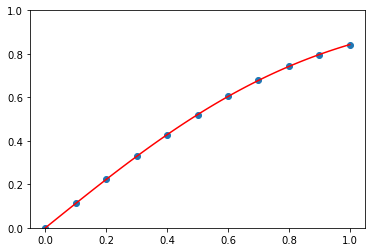

In [31]:
# All of these curves pretty much just follow the graph of the function on this interval,
# so I include only one graph. Coefficients are included below


plt.scatter(xk,yk)
plt.plot(x_plot,plots[7],color='red')
#plt.plot(x_plot, sp.erf(x_plot), color='green')
plt.ylim([0,1])

In [48]:
error = []

for i in range(k-1):
    max_error = np.max(np.abs(sp.erf(x_plot)-plots[i]))
    error.append(max_error)

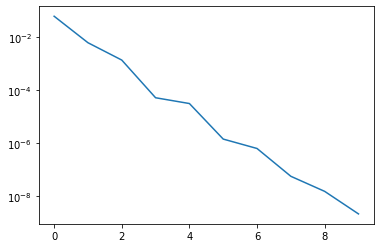

In [50]:
plt.semilogy(error)

Error appears to decrease exponentially with degree

### Part c

In [59]:
coeffs2 = []

plots2 = []

for i in range(10):
    deg = i
    A = np.zeros((k,deg))
    for j in range(deg):
        A[:,j] = xk**(2*j+1)
    coeffs2.append(np.linalg.lstsq(A,yk,rcond=None)[0])
    
    
    # the next two lines don't actually need to be included in this loop but oh well
    m_plot = 100
    x_plot = np.linspace(0,1,m_plot)
    
    
    A_plot = np.zeros((m_plot,deg))
    for j in range(deg):
        A_plot[:,j] = x_plot**(2*j+1)
    y_plot = A_plot.dot(coeffs2[i])
    
    plots2.append(y_plot)
    


In [60]:
error2 = []

for i in range(k-1):
    max_error = np.max(np.abs(sp.erf(x_plot)-plots2[i]))
    error2.append(max_error)

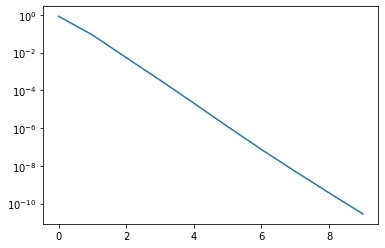

In [61]:
plt.semilogy(error2)

In [64]:
# the above appears to decrease exponentially with increase in degree

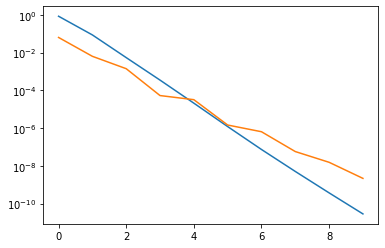

In [65]:
plt.semilogy(error2)
plt.semilogy(error)

### part d

In [78]:
A = np.ones((k,5))
for i in range(4):
    A[:,i+1] = np.exp(-xk**2)/(1+xk)**i
coefficients = np.linalg.lstsq(A,yk,rcond=None)[0]

In [87]:
A.dot(coefficients)

array([7.68662993e-06, 1.12436205e-01, 2.22719385e-01, 3.28646693e-01,
       4.28390148e-01, 5.20481352e-01, 6.03840746e-01, 6.77803342e-01,
       7.42119247e-01, 7.96924040e-01, 8.42682908e-01])

In [100]:
m_plot = 100
x_plot = np.linspace(0,1,m_plot)

A_plot = np.ones((m_plot,5))
for j in range(4):
    A_plot[:,j+1] = np.exp(-x_plot**2)/(1+x_plot)**j
y_plot = A_plot.dot(coefficients)

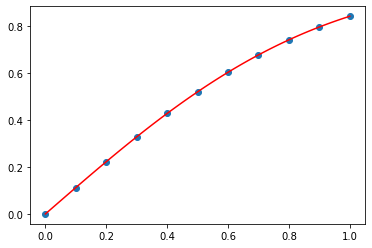

In [101]:
plt.scatter(xk,yk)
plt.plot(x_plot,y_plot,color='red')
#plt.ylim([0,1])

In [102]:
new_error = np.max(np.abs(sp.erf(x_plot)-y_plot))

new_error

3.873227419463887e-05

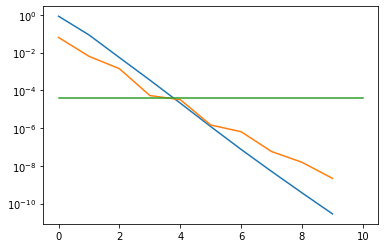

In [103]:
plt.semilogy(error2)
plt.semilogy(error)
plt.semilogy(np.ones(k)*new_error)

In [108]:
new_error, error[4],error2[4]

(3.873227419463887e-05, 3.200898505331673e-05, 2.0945308512265726e-05)

The error of this approximation is approximately the same as on this interval (same up to order). However, consider the following:

In [109]:
m_plot = 100
x_plot = np.linspace(0,10,m_plot)

A_plot = np.ones((m_plot,5))
for j in range(4):
    A_plot[:,j+1] = np.exp(-x_plot**2)/(1+x_plot)**j
y_plot = A_plot.dot(coefficients)

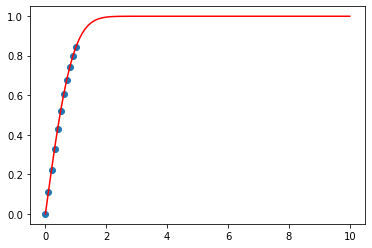

In [110]:
plt.scatter(xk,yk)
plt.plot(x_plot,y_plot,color='red')
#plt.ylim([0,1])

The new approximation will be bounded and tend to 1